In [1]:
import re
import pickle
import efmtool
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
FIXED_UPTAKE = 10  # uptake fixed in uranium_v3.ipynb

In [3]:
with open('tested_growth_rates.pkl', 'rb') as f:
    simulated_mus = pickle.load(f)

In [4]:
c_sources = {
    "Geobacter": {"mEmC_1": "M_mal__45__L_e",
                  "mEmC_2": "M_mal__45__L_e",
                  "mEmC_3": "M_mal__45__L_e",
                  "mEmC_4": "M_mal__45__L_e",
                  "mEmC_5": "M_cit_e",
                  "mEmC_6": "M_cit_e",
                  "mE_1": "M_mal__45__L_e"},
    "Rhodoferax": {"mEmC_1": "M_fum_e",
                   "mEmC_3": "M_fum_e",
                   "mEmC_2": "M_cit_e",
                   "mEmC_4": "M_cit_e",
                   "mEmC_5": "M_mal__45__L_e",
                   "mEmC_6": "M_mal__45__L_e",
                   "mE_1": "M_ac_e"}
    }

In [5]:
growing_ecms = {}
for model in ["Rhodoferax", "Geobacter"]:
    print(f" * {model}")
    growing_ecms[model] = {}
    for code, growth_rates in simulated_mus.items():
        print(code)
        growing_ecms[model][code] = {}
        
        all_yields = []
        all_mus = []
        
        for mu in growth_rates:
            mu = round(mu, 2)
            ecms = pd.read_csv(f"results/{model}_{code}_{mu}_full_conversions.csv")
            growing = ecms[ecms["objective"] > 1e-9]
            growing = growing.div(growing["virtual_tag_R_constraint_reaction"], axis=0)
            #growing = round(growing, 6).drop_duplicates()

            print(f"    {mu}: {len(growing)}")

            growing_ecms[model][code][mu] = growing
            yields = growing["objective"] / (FIXED_UPTAKE + growing["M_fixed_uptake"])
            
            all_yields.extend(abs(yields).tolist())
            all_mus.extend([mu] * len(yields))

        # plot_df = pd.DataFrame({"Biomass yield": all_yields, "mu": all_mus})
        # sns.stripplot(data=plot_df, x="mu", y="Biomass yield")
        # plt.title(f"{model} {code}")
        # plt.xlabel("Growth rate")
        # plt.show()

 * Rhodoferax
mEmC_1
    0.66: 12
    0.6: 70
    0.54: 72
    0.47: 72
    0.4: 72
    0.33: 190
    0.27: 267
    0.2: 319
    0.13: 365
mEmC_3
    0.66: 12
    0.6: 70
    0.54: 72
    0.47: 72
    0.4: 72
    0.33: 190
    0.27: 267
    0.2: 319
    0.13: 365
mEmC_2
    0.99: 13
    0.9: 13
    0.8: 13
    0.7: 13
    0.6: 44
    0.5: 112
    0.4: 188
    0.3: 435
    0.2: 646
mEmC_4
    0.92: 13
    0.84: 13
    0.74: 13
    0.65: 44
    0.56: 76
    0.46: 137
    0.37: 207
    0.28: 453
    0.19: 664
mEmC_5
    0.66: 12
    0.6: 70
    0.54: 72
    0.47: 72
    0.4: 72
    0.33: 94
    0.27: 154
    0.2: 188
    0.13: 222
mEmC_6
    0.32: 44
    0.29: 62
    0.26: 94
    0.23: 94
    0.2: 108
    0.16: 126
    0.13: 164
    0.1: 170
    0.07: 170
mE_1
    0.37: 28
    0.33: 48
    0.3: 48
    0.26: 68
    0.22: 72
    0.18: 100
    0.15: 110
    0.11: 120
    0.07: 120
 * Geobacter
mEmC_1
    0.66: 71
    0.6: 144
    0.54: 156
    0.47: 165
    0.4: 201
    0.33: 209
    0.27: 2

In [6]:
all_dimes = {"Rhodoferax": {
            "mEmC_1": {
                "uptakes": ["M_fe2_e"],#, "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_3": {
                "uptakes": ["M_fe2_e"],#, "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_2": {
                "uptakes": ["M_fe2_e"],#, "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_4": {
                "uptakes": ["M_fe2_e"],#, "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_5": {
                "uptakes": ["M_fe2_e"],#, "M_mal__45__L_e"],
                "secretion": []},
            "mEmC_6": {
                "uptakes": ["M_fe2_e", "M_co2_e"], # "M_mal__45__L_e",
                "secretion": []},
            "mE_1": {
                "uptakes": [],#"M_ac_e"],
                "secretion": []}
},
        "Geobacter": {
            "mEmC_1": {
                "uptakes": [],#"M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_2": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_3": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_4": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_5": {
                "uptakes": [],#["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e"]},
            "mEmC_6": {
                "uptakes": [],#["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e", "M_co2_e"]},
            "mE_1": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_ac_e"]}
        }}

#sec_only = ["M_h2_e"]

In [7]:
filtered_ecms = {}
for model, dimes in all_dimes.items():
    filtered_ecms[model] = {}
    for dime_number, dime in dimes.items():
        print(model, dime_number)

        filtered_ecms[model][dime_number] = {}
        for mu, ecms in growing_ecms[model][dime_number].items():

            # filter out ecms with a specific pattern
            sec_cols = dime["secretion"]
            filtered = ecms[(ecms[sec_cols] > 0).all(axis=1)]
            uptake_cols = dime["uptakes"]
            filtered = filtered[(filtered[uptake_cols] < 0).all(axis=1)]

            # add back uptake column based on slack variable column
            filtered[c_sources[model][dime_number]] = -FIXED_UPTAKE - filtered["M_fixed_uptake"]
            filtered = filtered.drop(columns=["M_fixed_uptake"])
            filtered = filtered.loc[:, (filtered != 0).any(axis=0)]
    
    
            # remove columns that are just zeros
            filtered_ecms[model][dime_number][mu] = filtered
    
            filtered.to_csv(f"results/filtered_ecms_{model}_{dime_number}_{mu}.csv")
    
            print(f"  {mu}: {len(filtered)}/{len(ecms)} ECMs")

Rhodoferax mEmC_1
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
  0.13: 76/365 ECMs
Rhodoferax mEmC_3
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
  0.13: 76/365 ECMs
Rhodoferax mEmC_2
  0.99: 1/13 ECMs
  0.9: 1/13 ECMs
  0.8: 1/13 ECMs
  0.7: 1/13 ECMs
  0.6: 4/44 ECMs
  0.5: 12/112 ECMs
  0.4: 22/188 ECMs
  0.3: 104/435 ECMs
  0.2: 163/646 ECMs
Rhodoferax mEmC_4
  0.92: 1/13 ECMs
  0.84: 1/13 ECMs
  0.74: 1/13 ECMs
  0.65: 4/44 ECMs
  0.56: 8/76 ECMs
  0.46: 15/137 ECMs
  0.37: 25/207 ECMs
  0.28: 113/453 ECMs
  0.19: 162/664 ECMs
Rhodoferax mEmC_5
  0.66: 12/12 ECMs
  0.6: 70/70 ECMs
  0.54: 72/72 ECMs
  0.47: 72/72 ECMs
  0.4: 72/72 ECMs
  0.33: 94/94 ECMs
  0.27: 154/154 ECMs
  0.2: 188/188 ECMs
  0.13: 222/222 ECMs
Rhodoferax mEmC_6
  0.32: 4/44 ECMs
  0.29: 6/62 ECMs
  0.

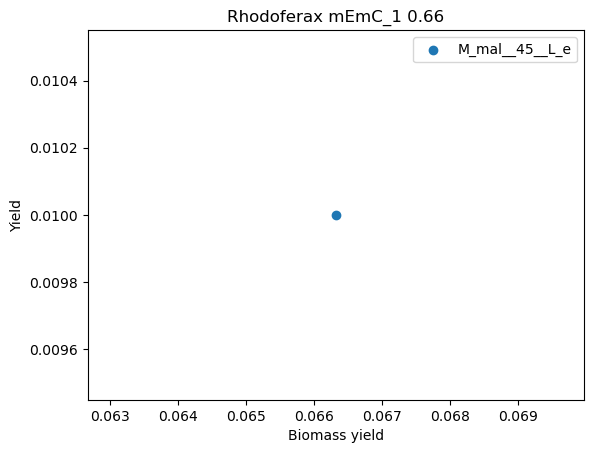

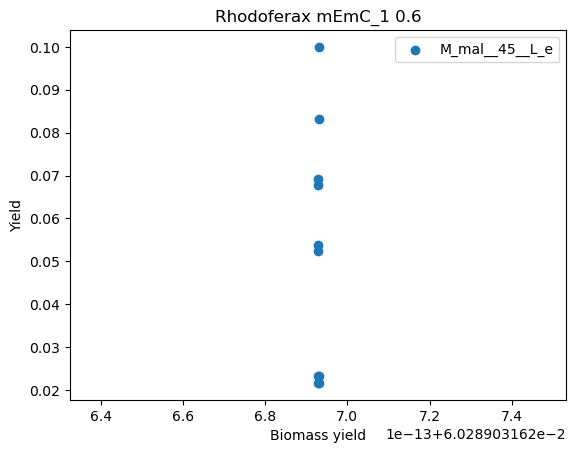

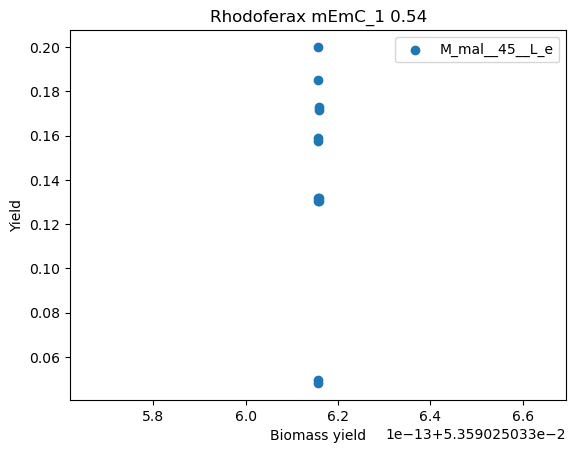

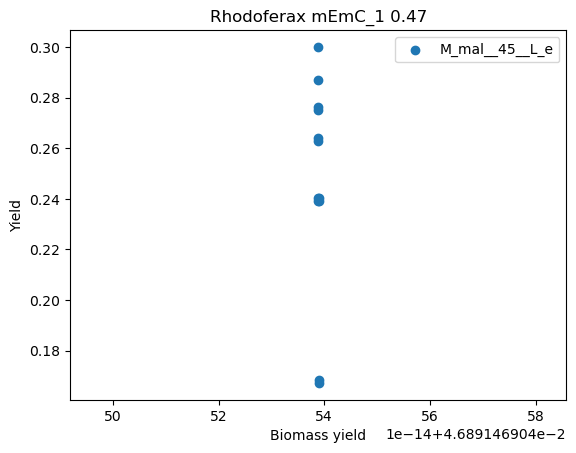

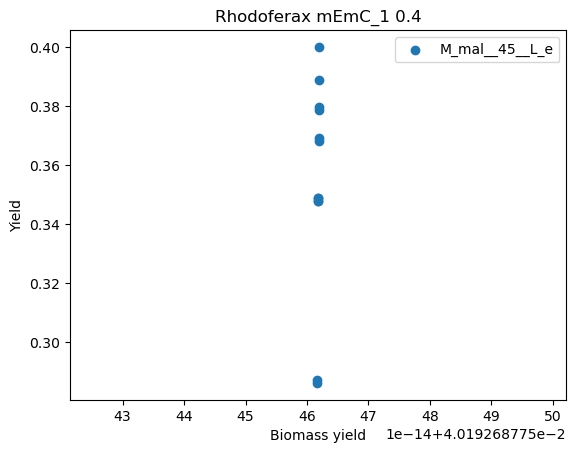

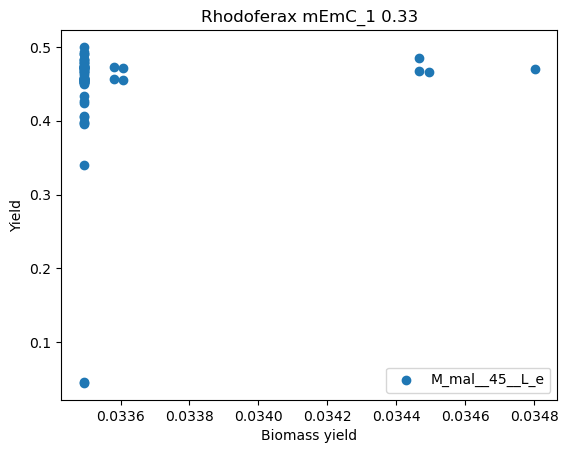

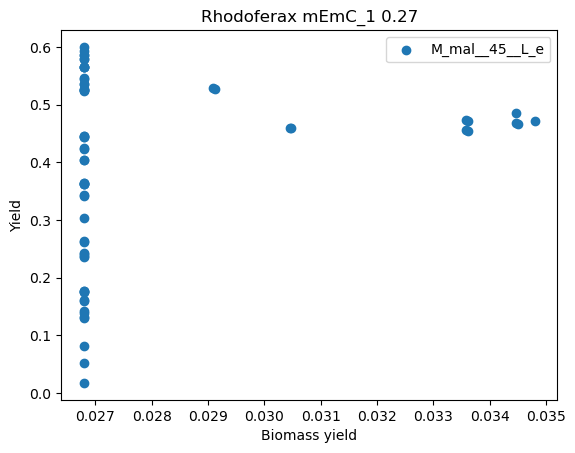

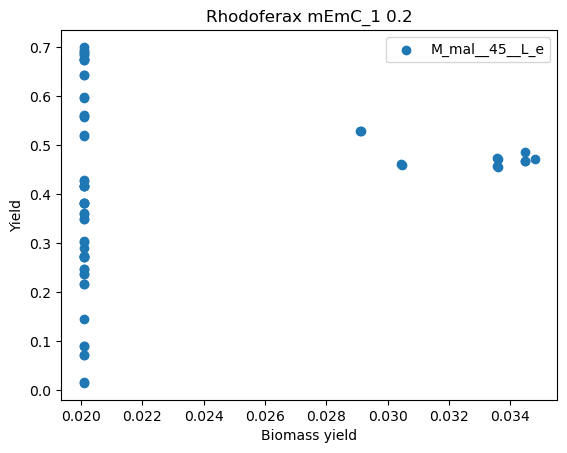

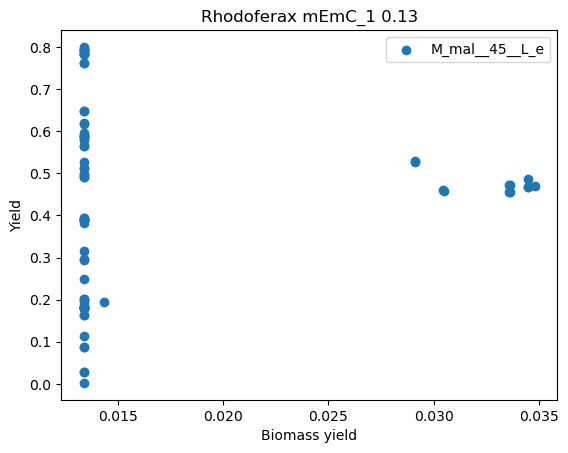

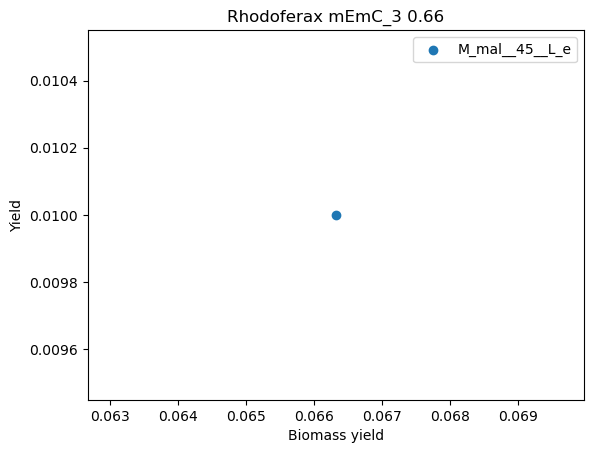

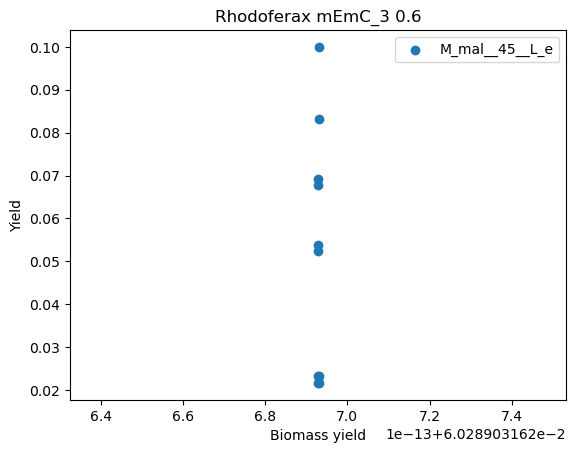

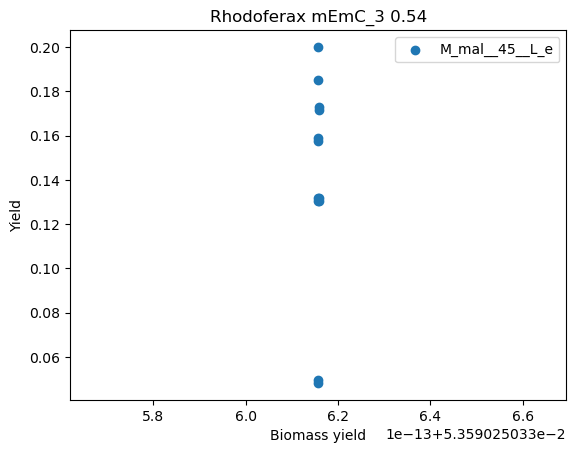

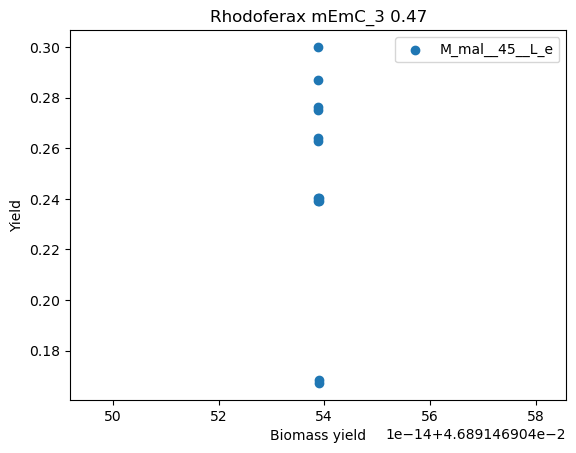

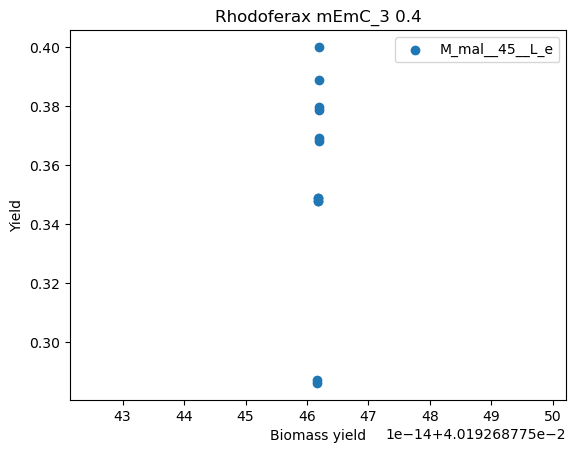

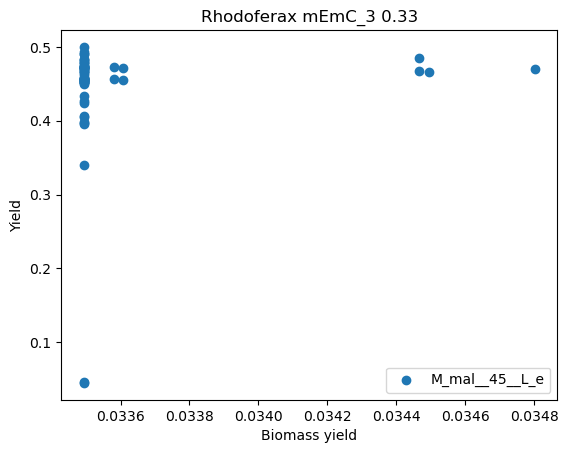

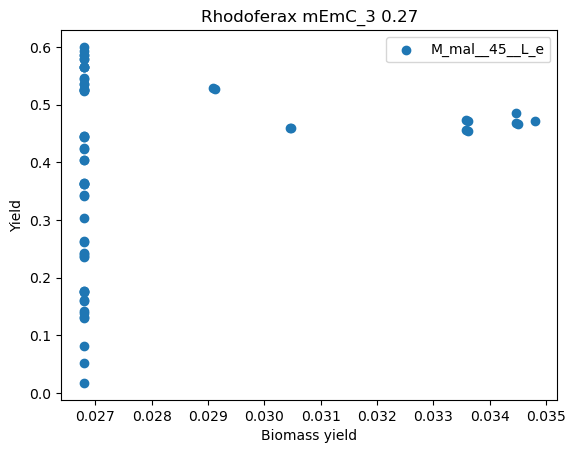

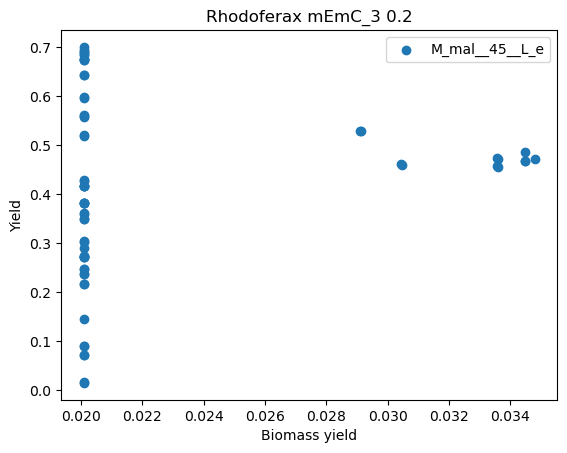

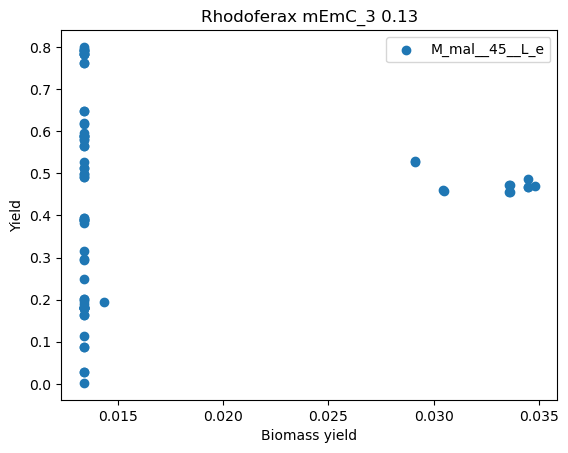

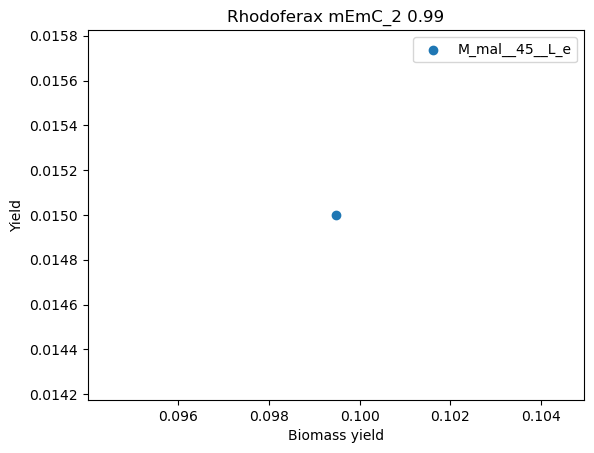

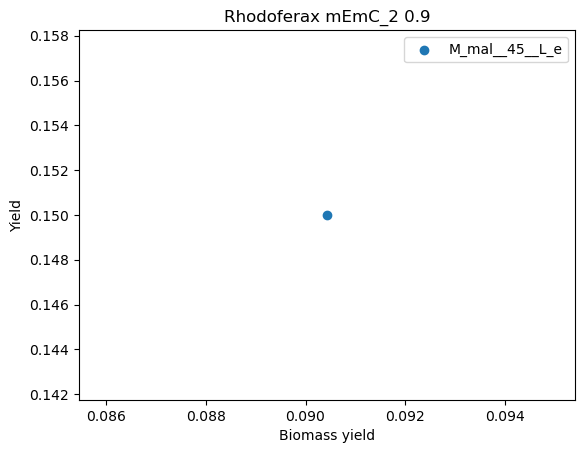

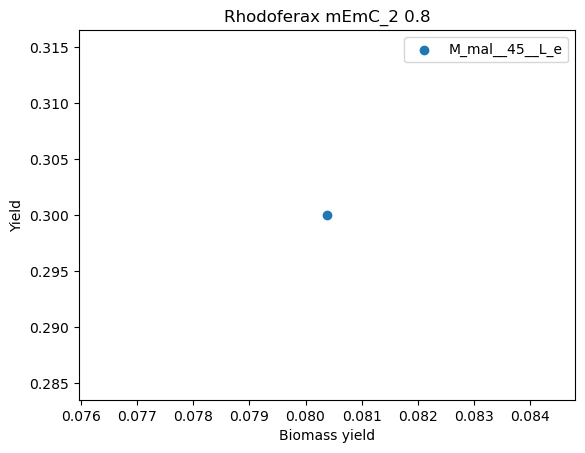

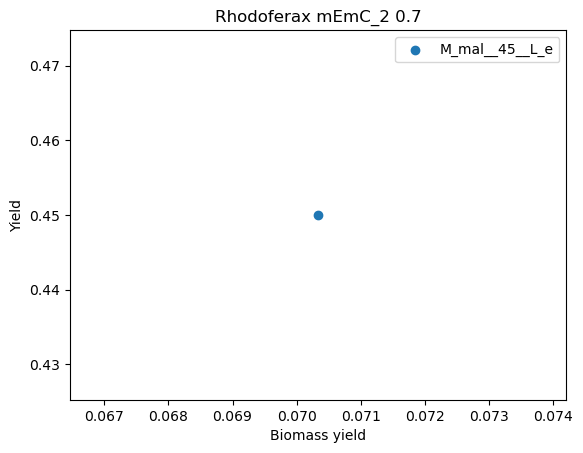

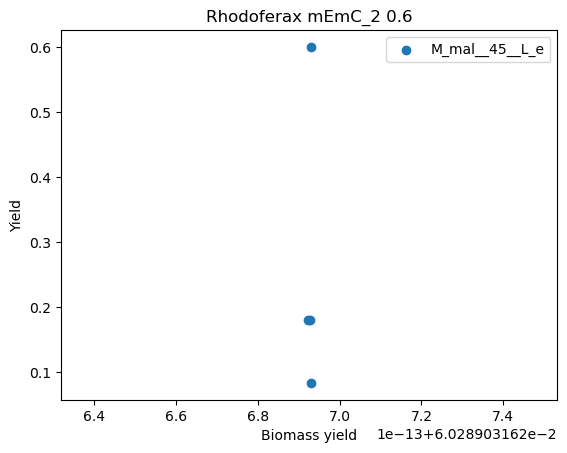

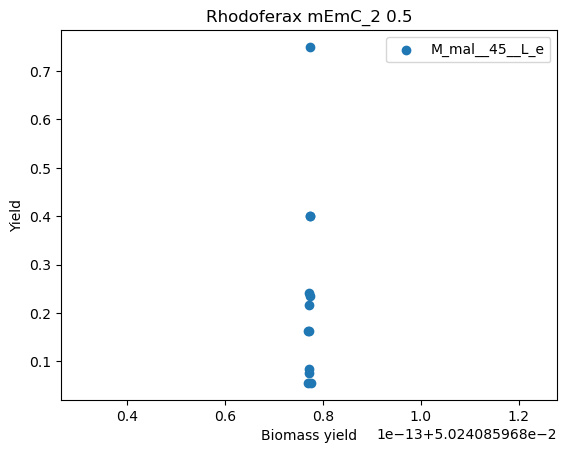

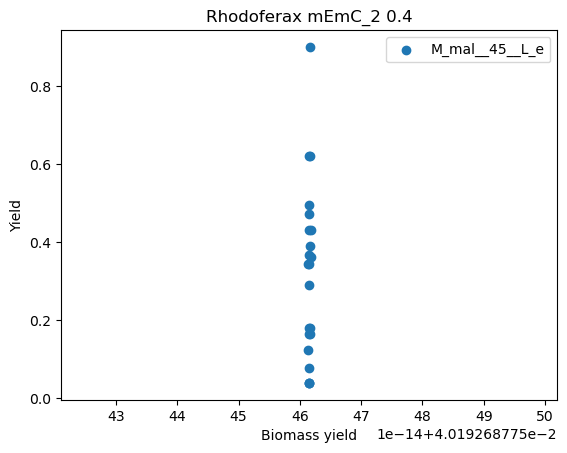

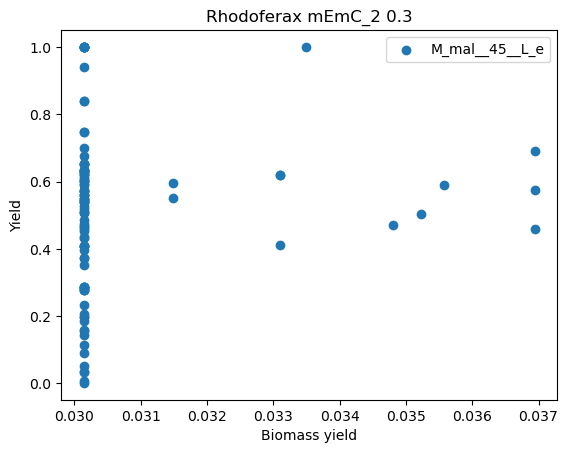

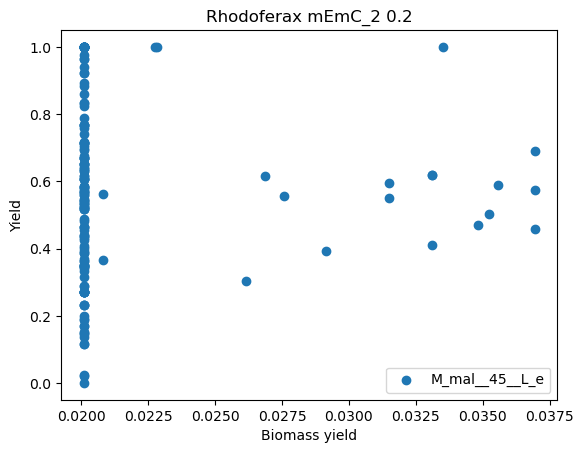

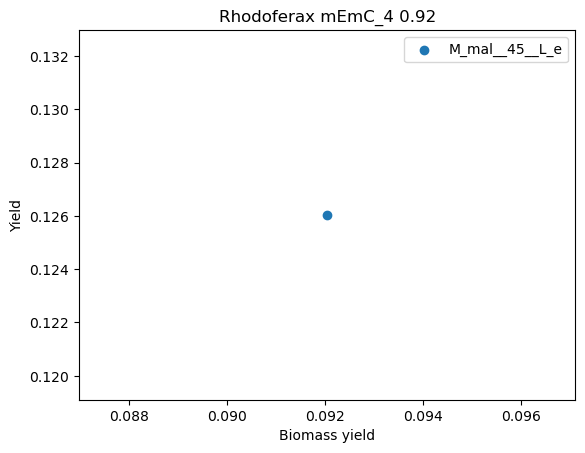

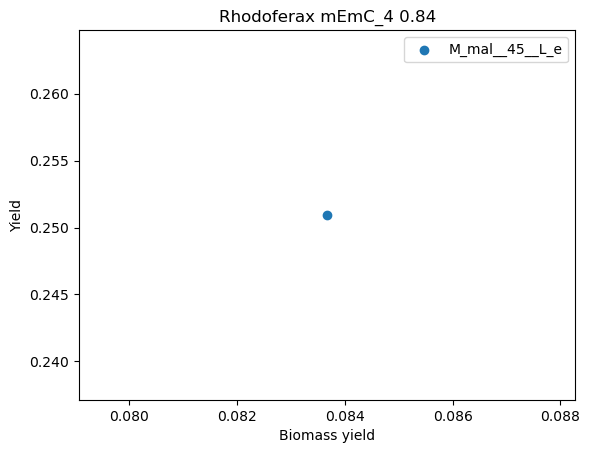

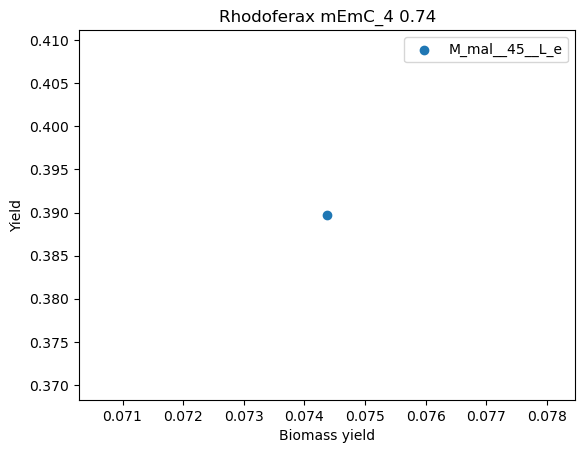

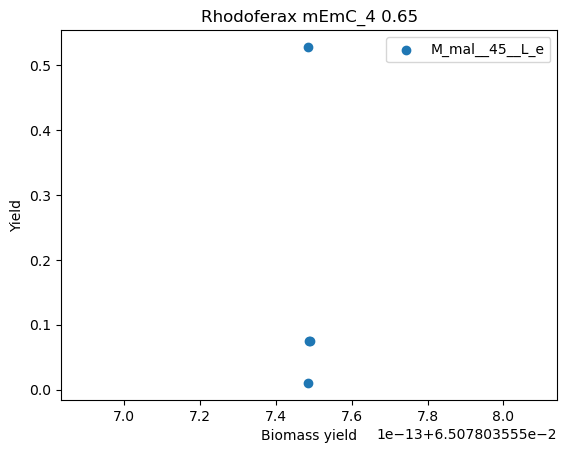

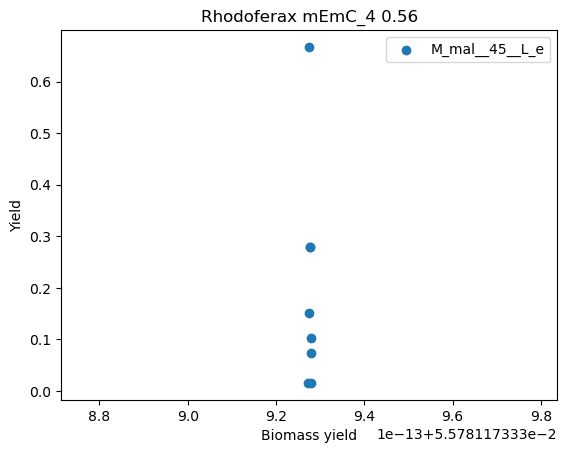

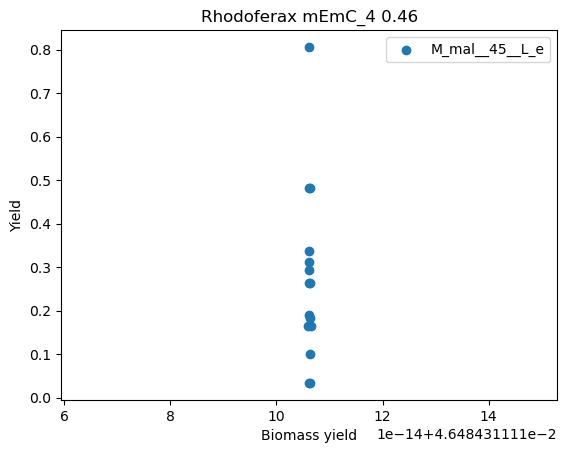

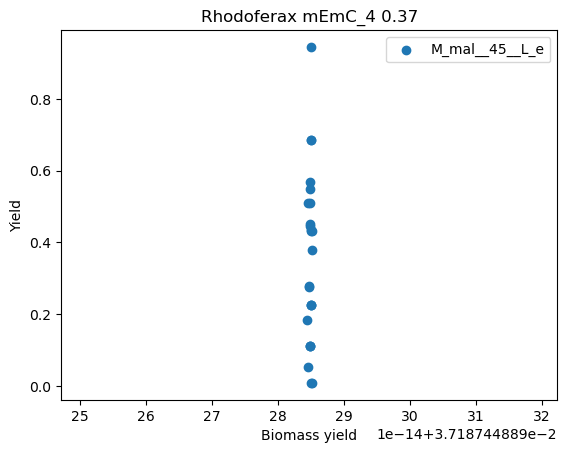

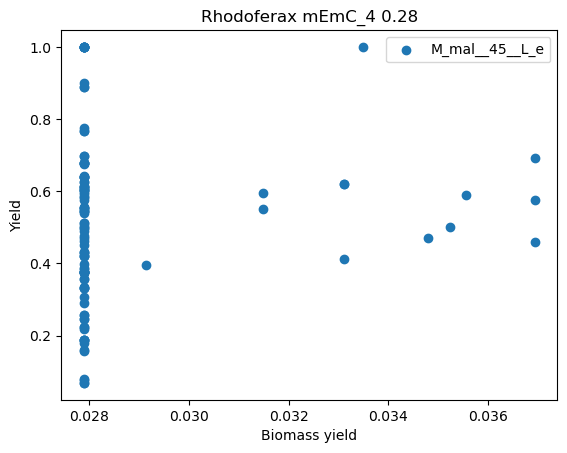

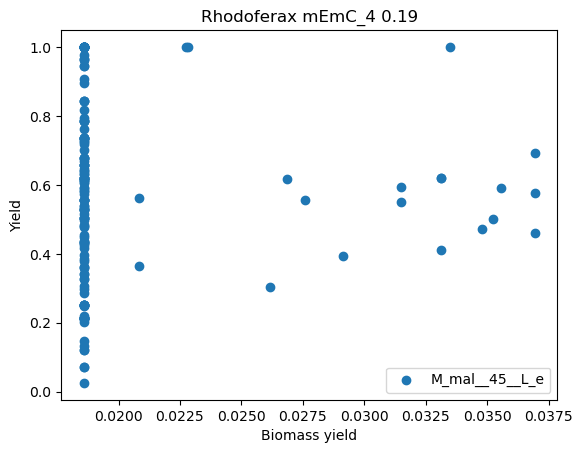

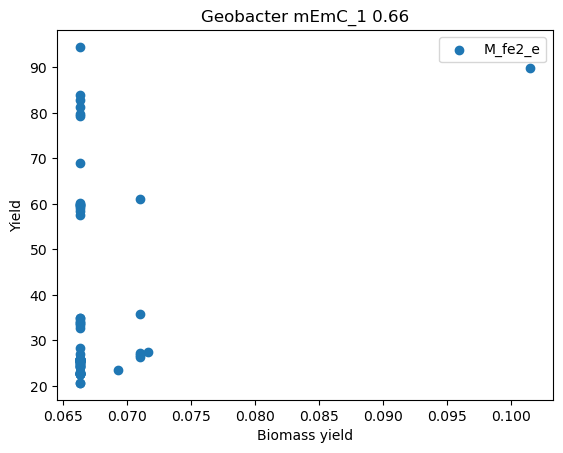

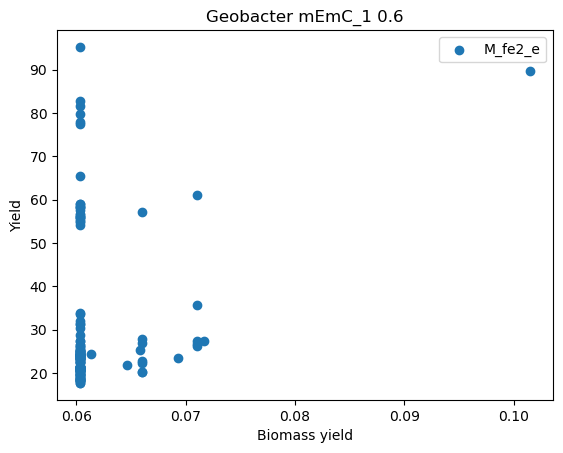

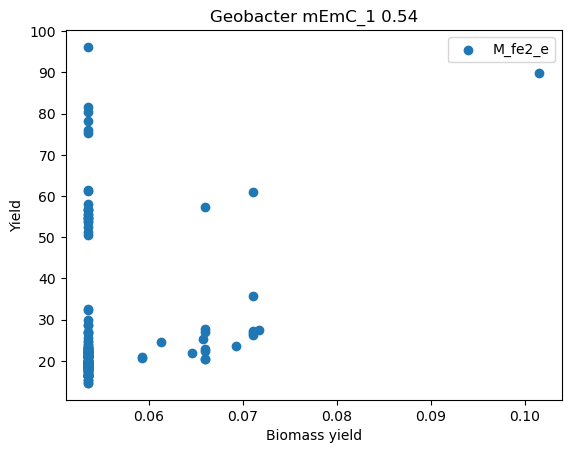

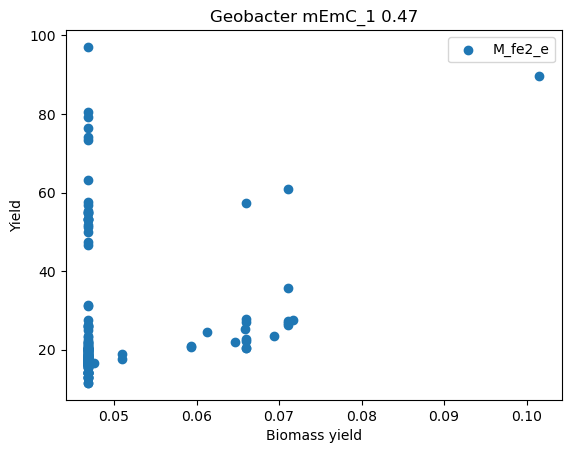

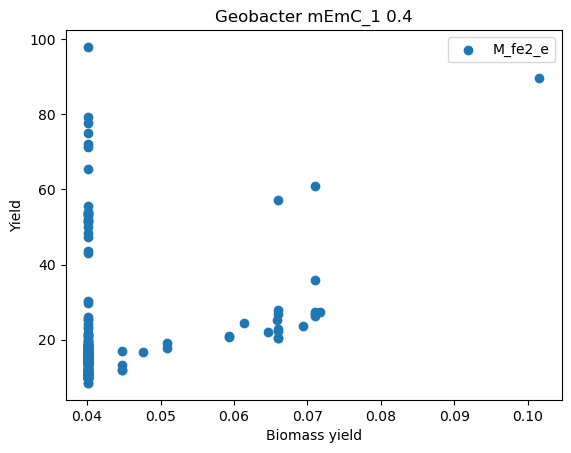

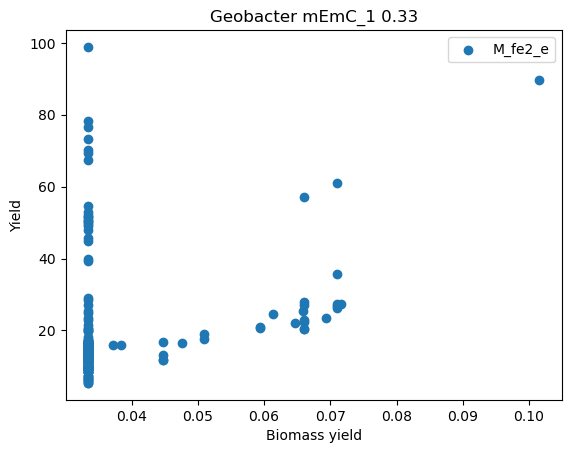

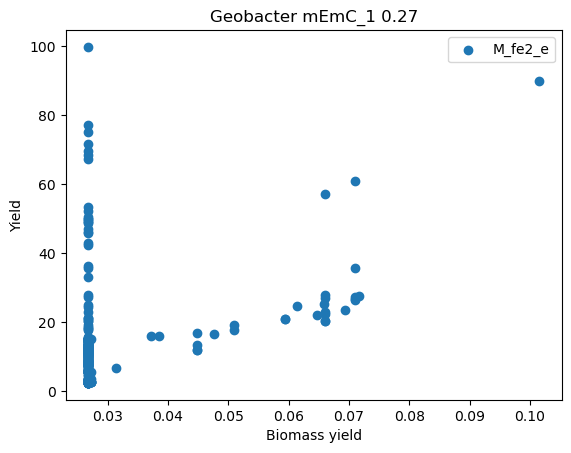

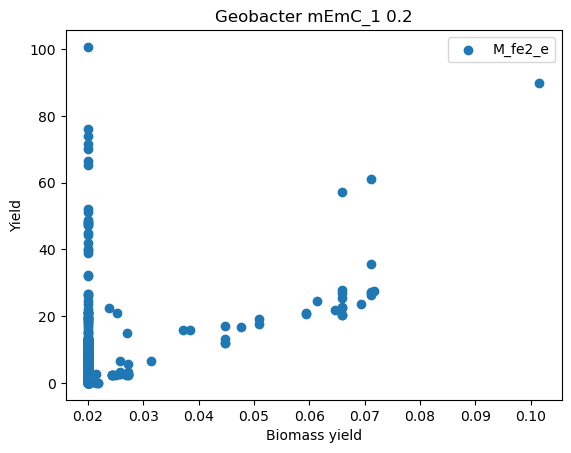

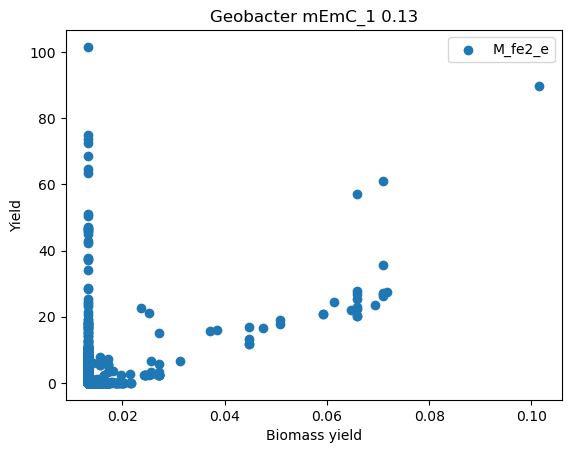

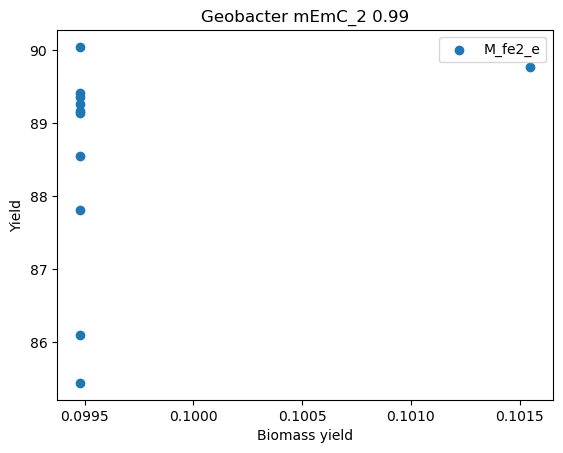

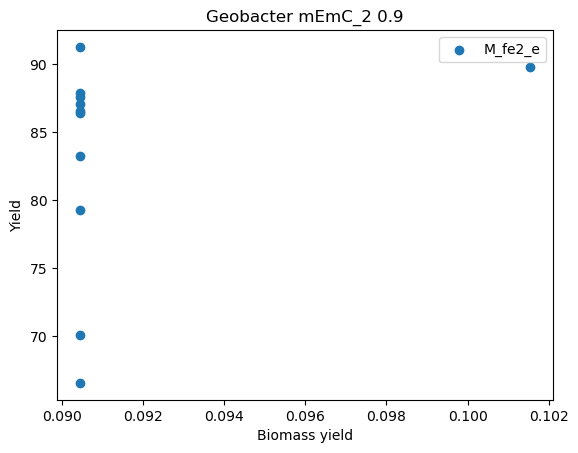

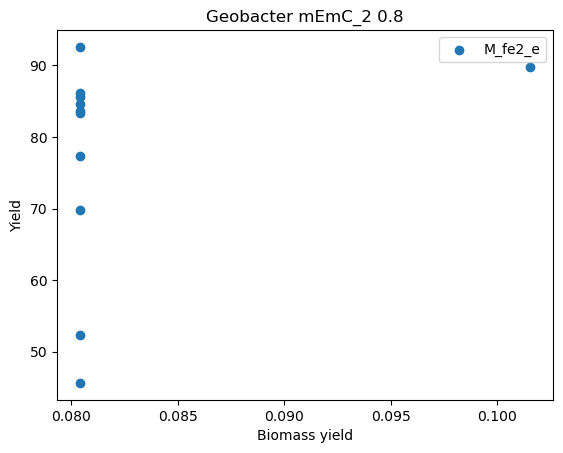

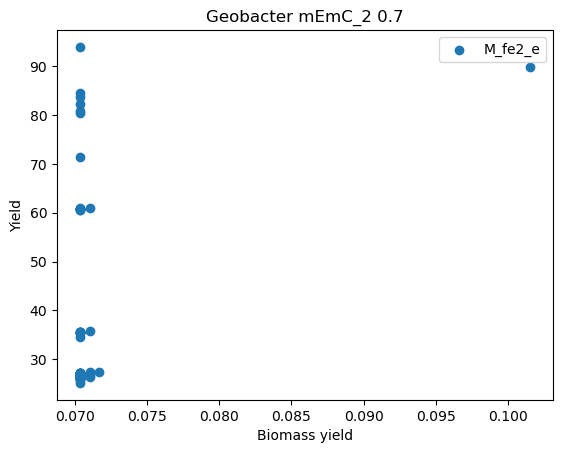

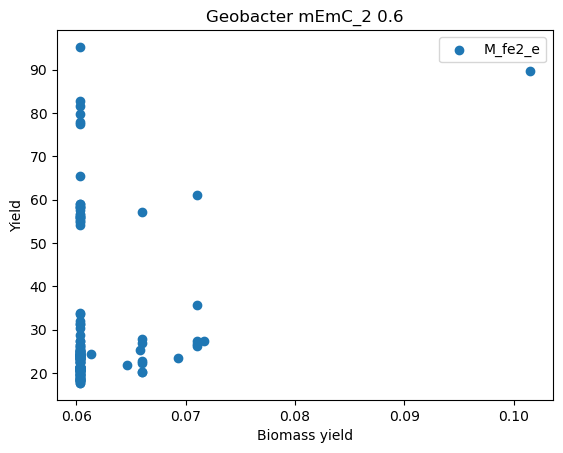

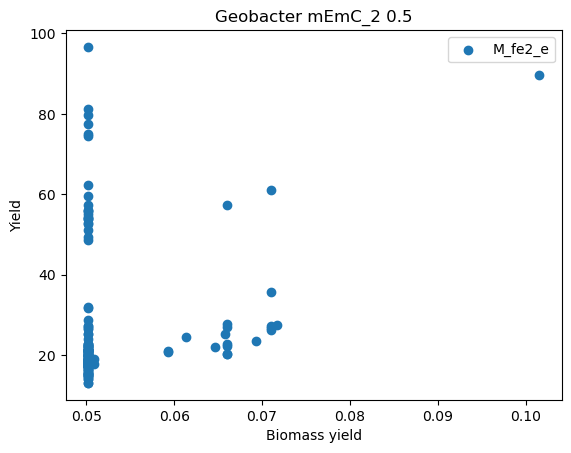

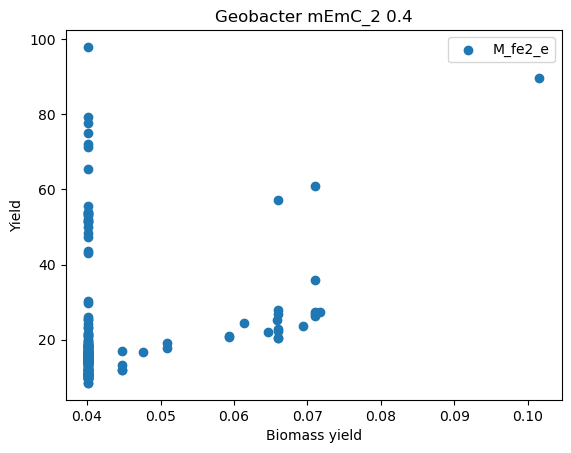

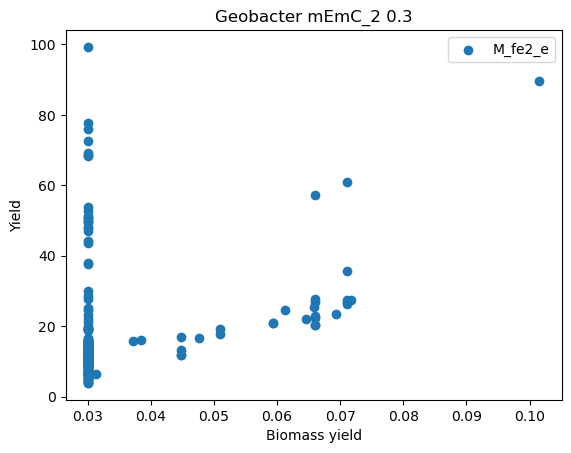

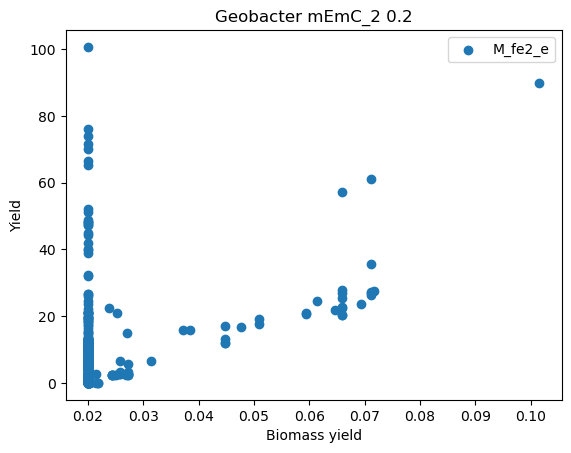

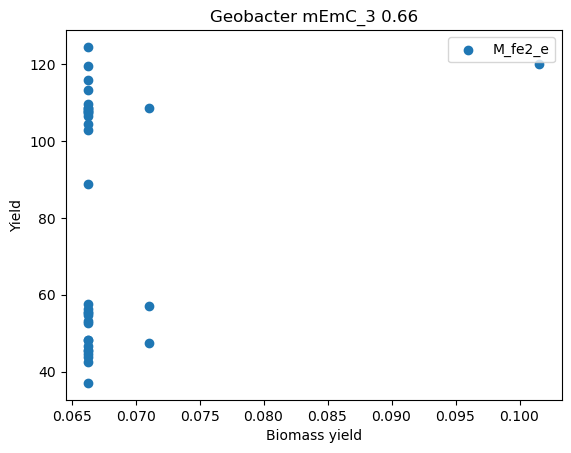

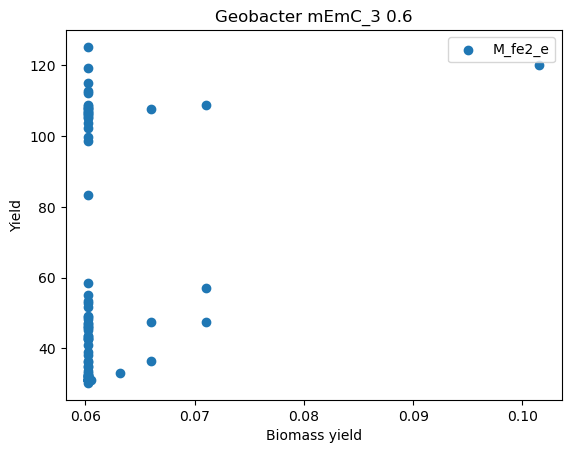

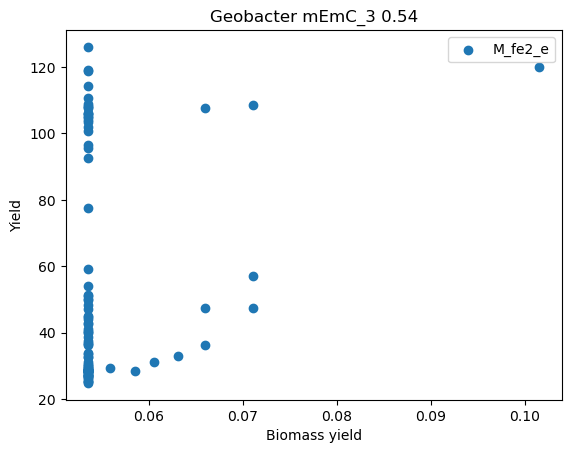

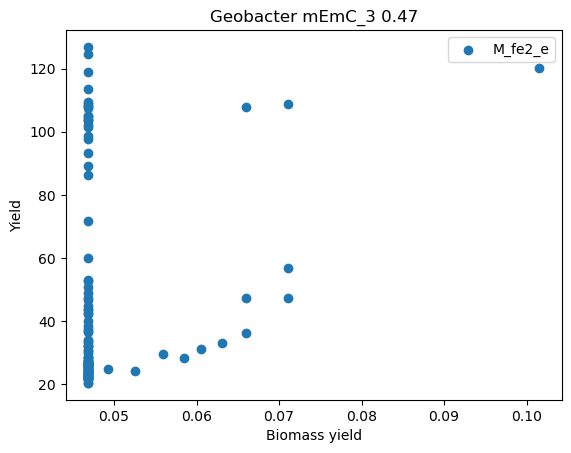

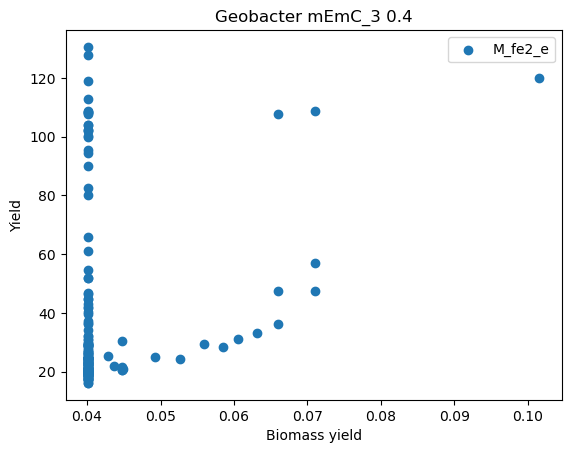

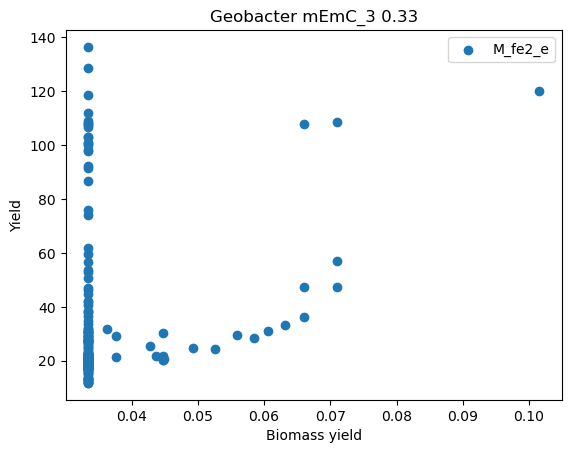

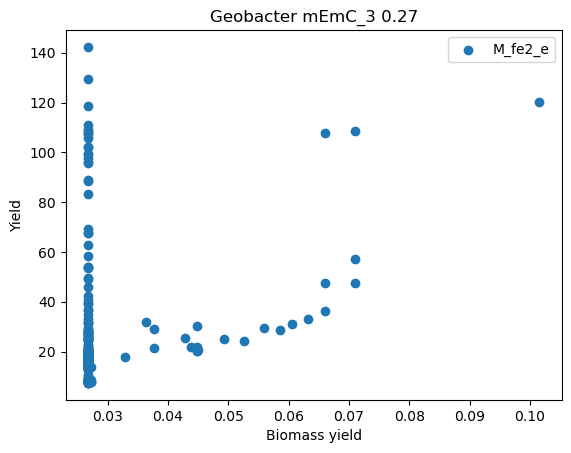

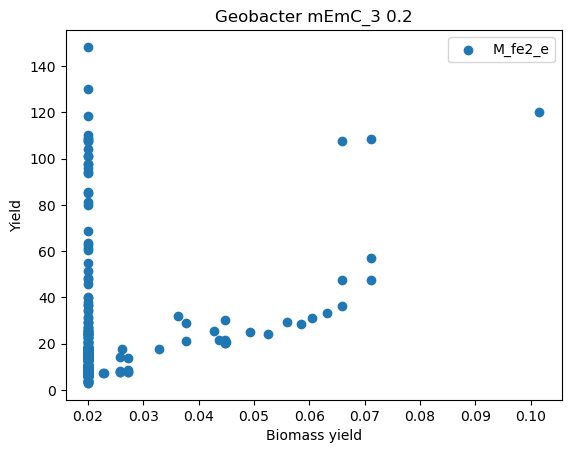

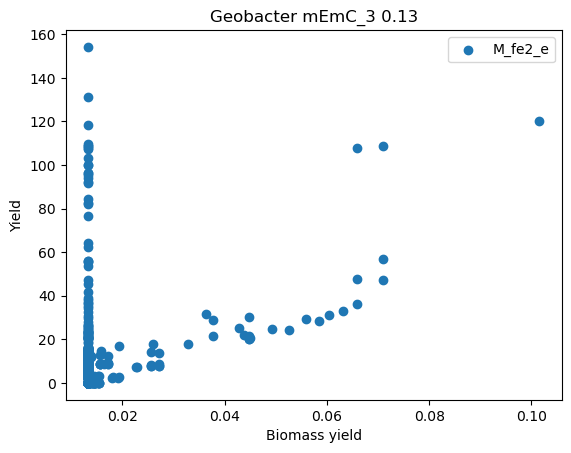

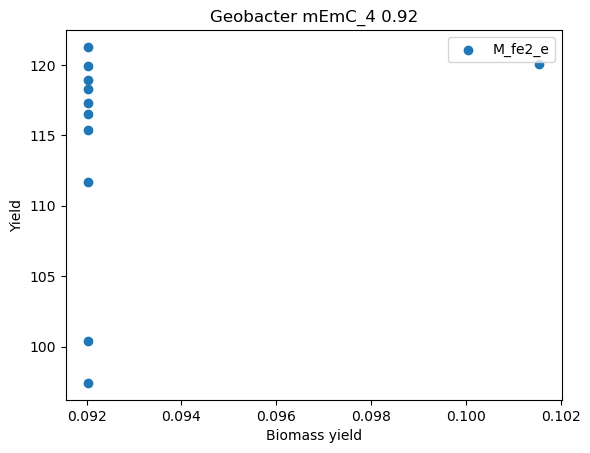

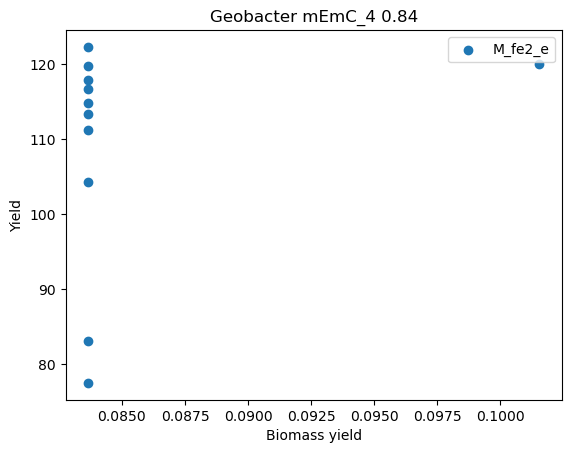

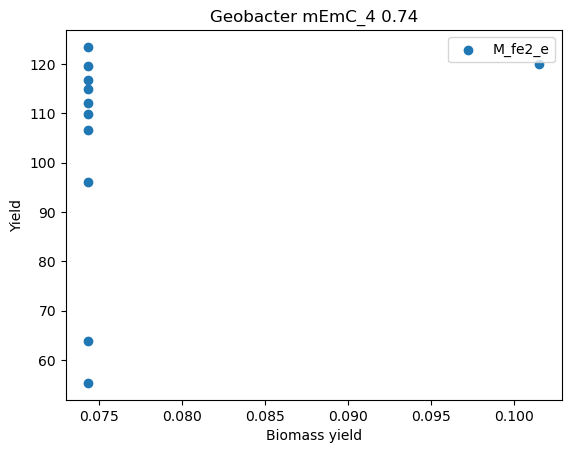

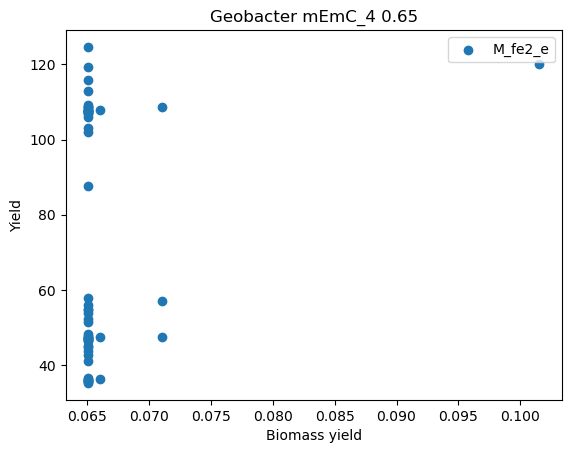

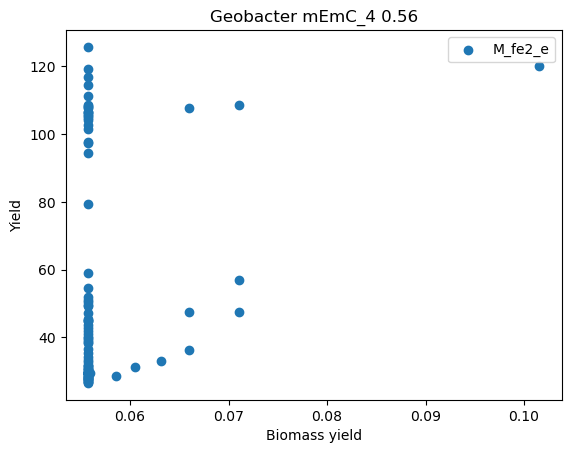

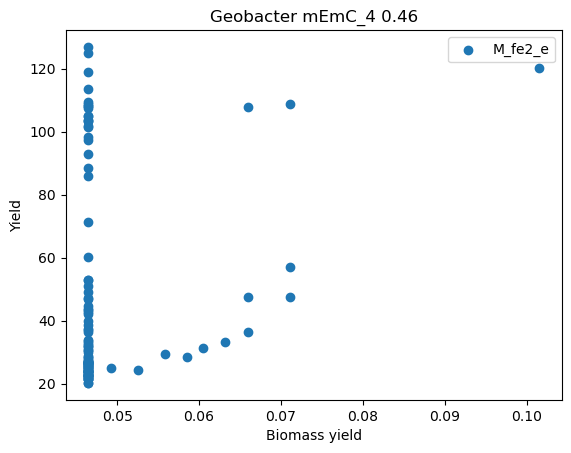

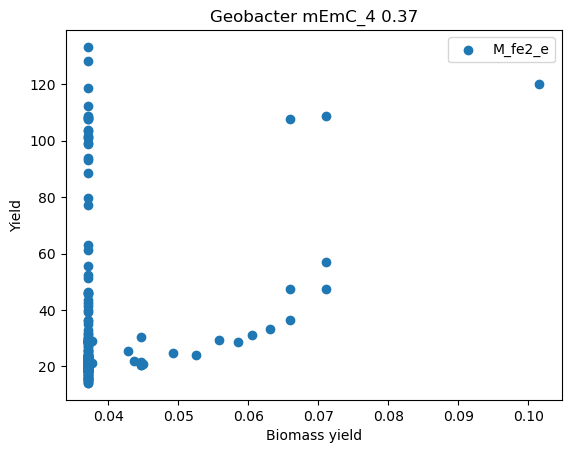

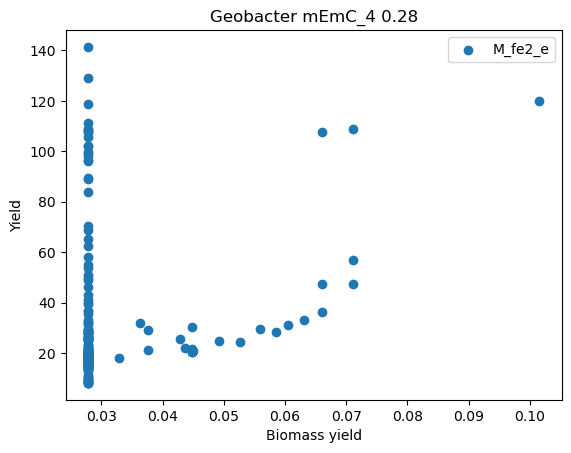

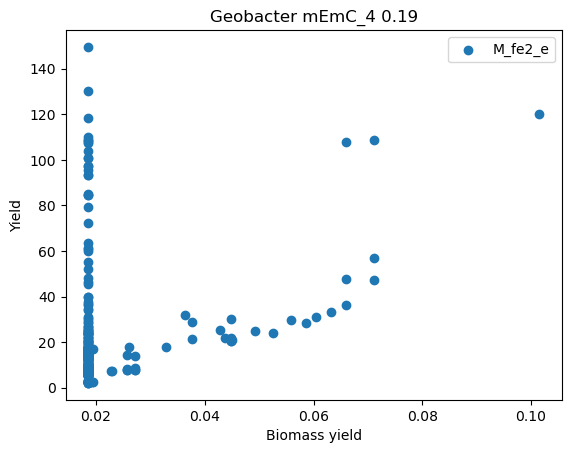

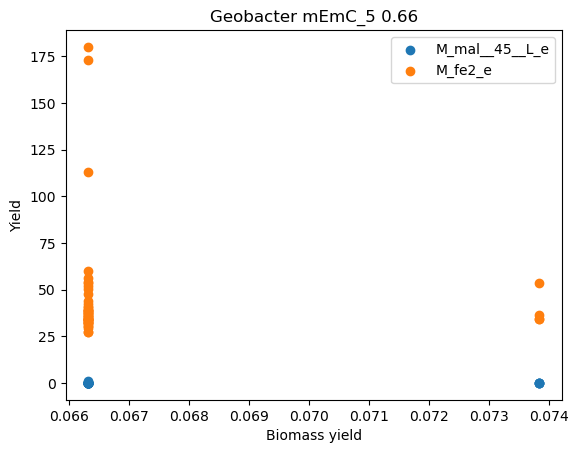

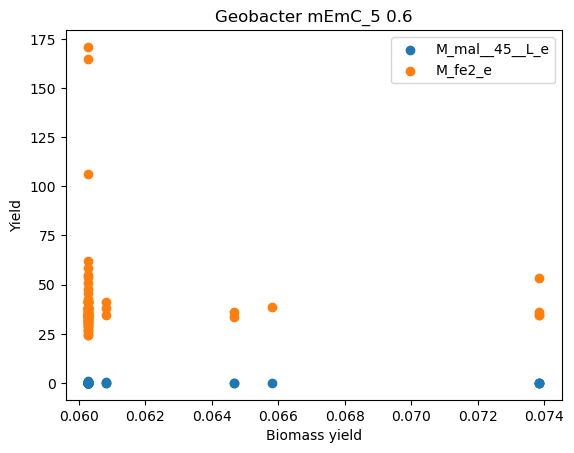

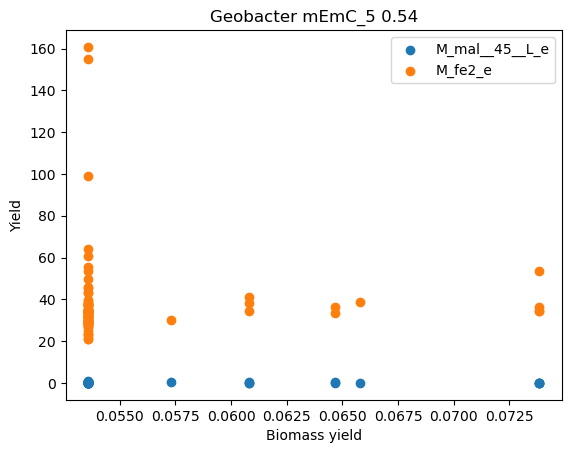

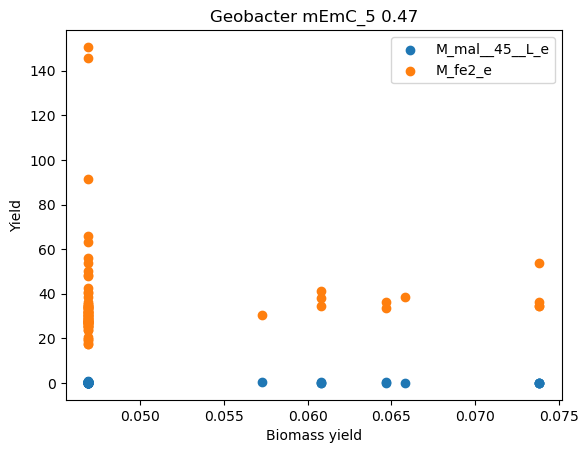

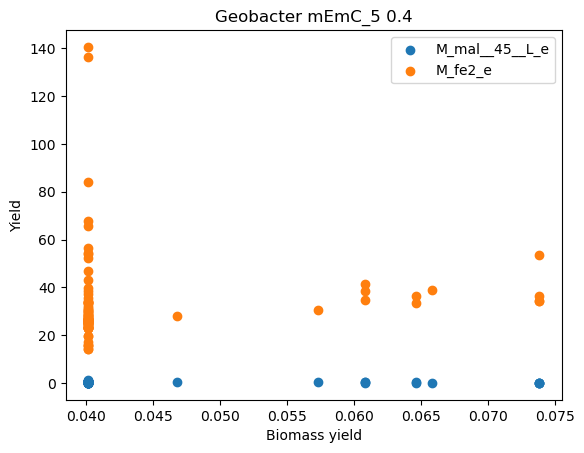

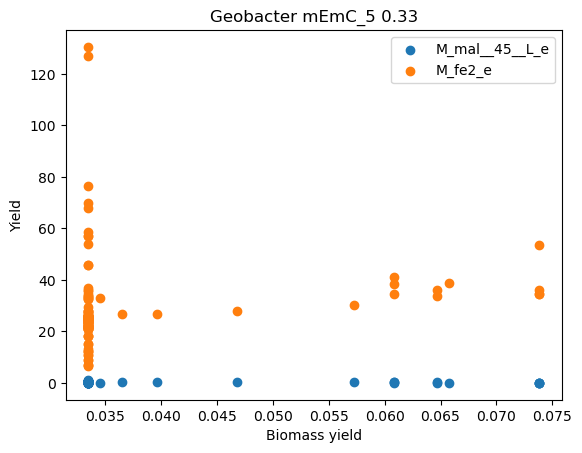

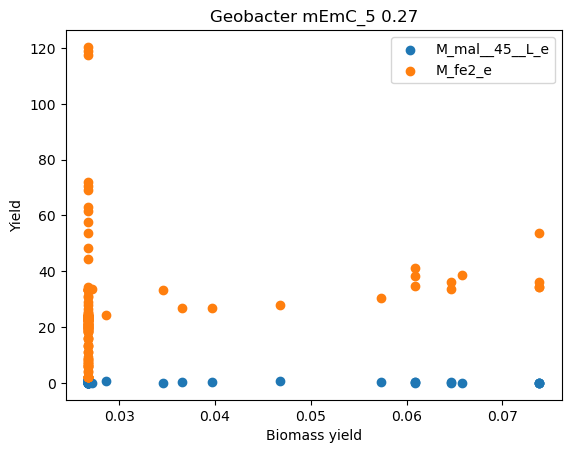

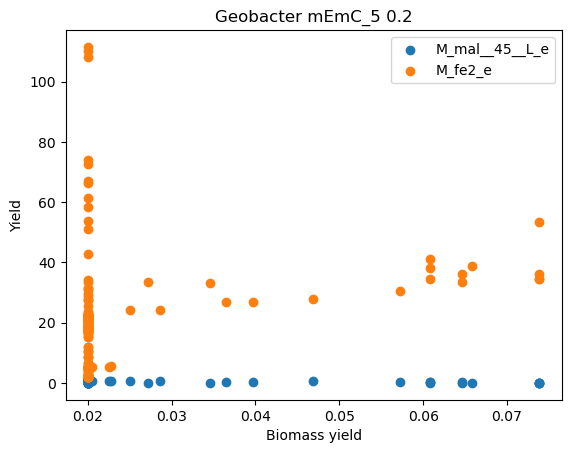

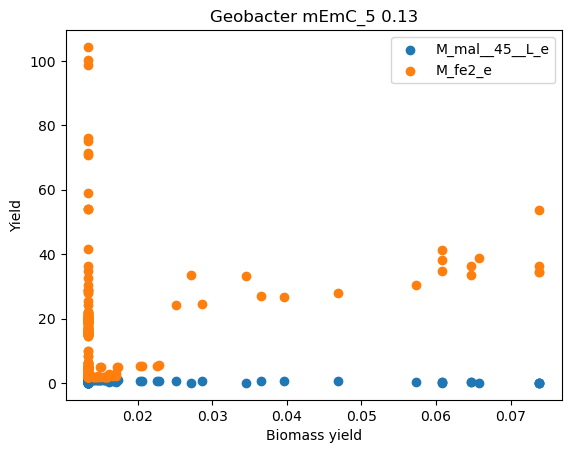

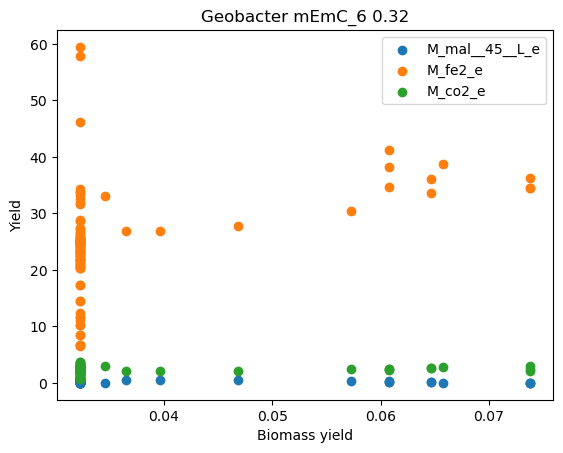

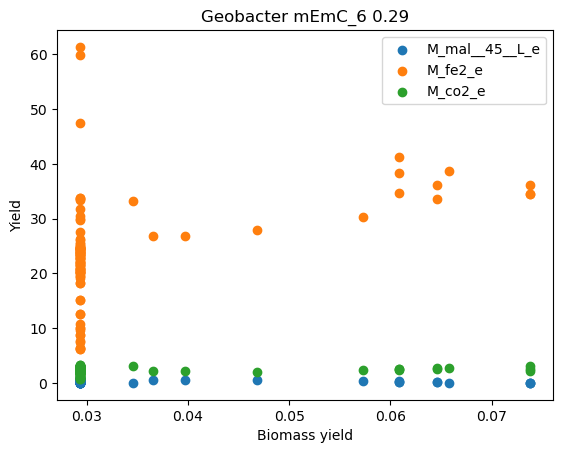

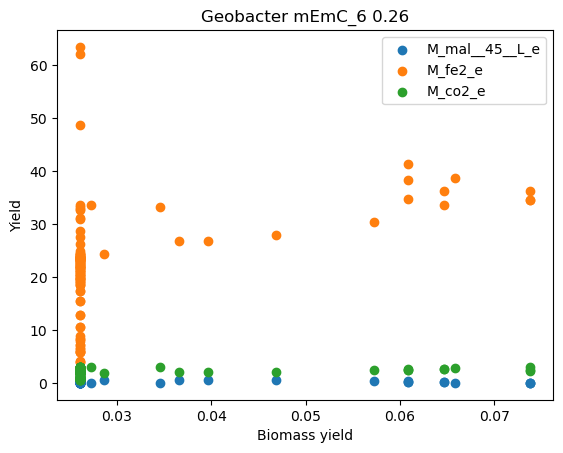

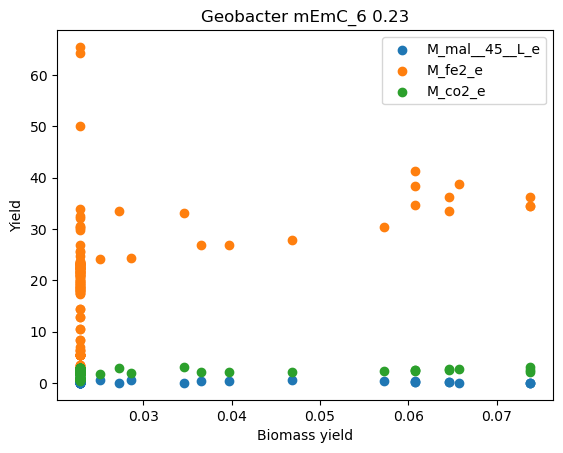

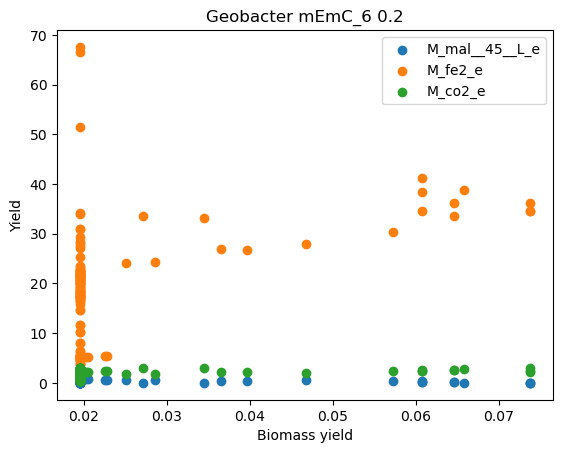

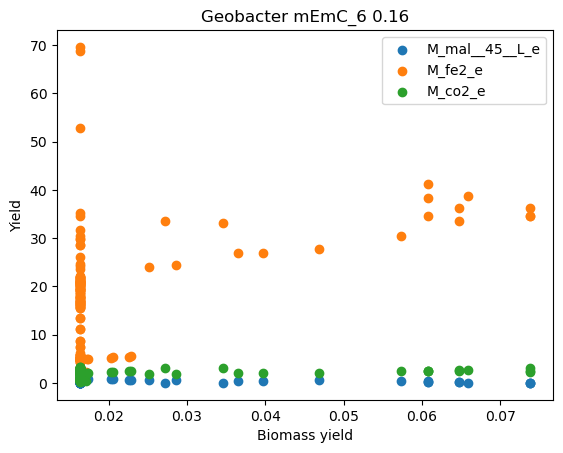

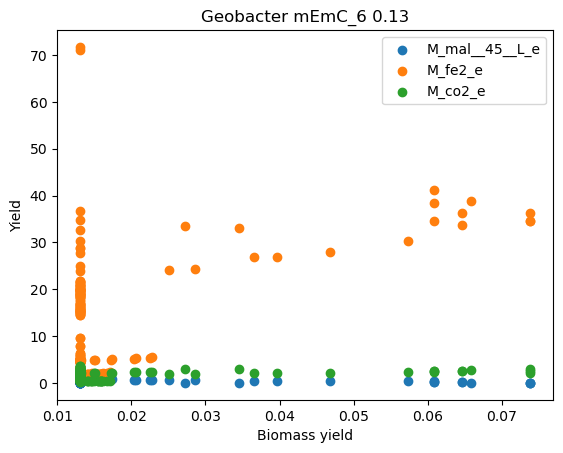

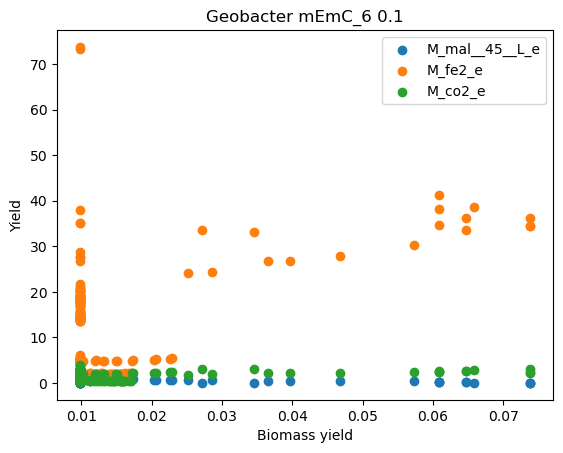

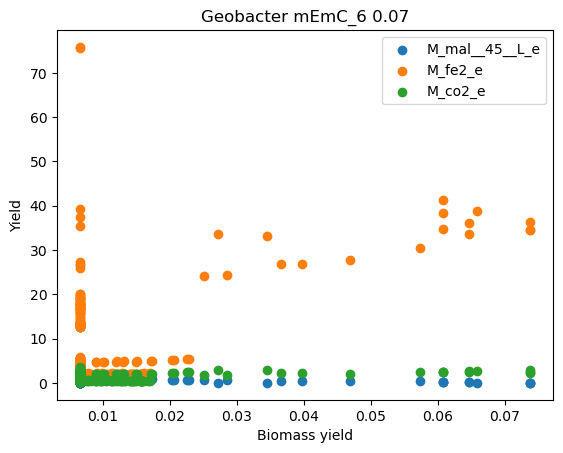

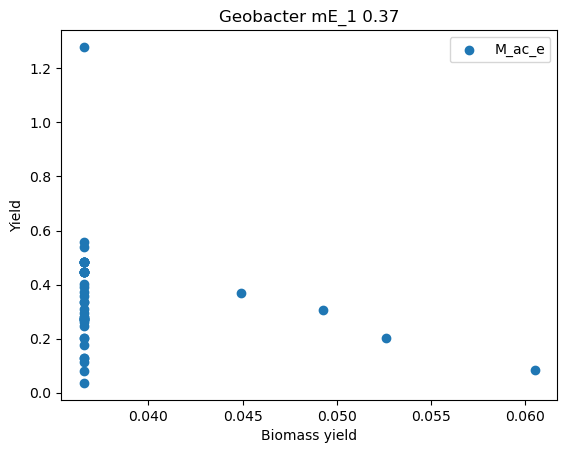

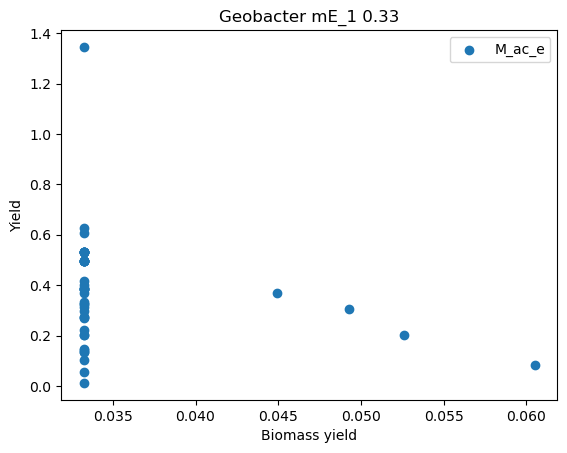

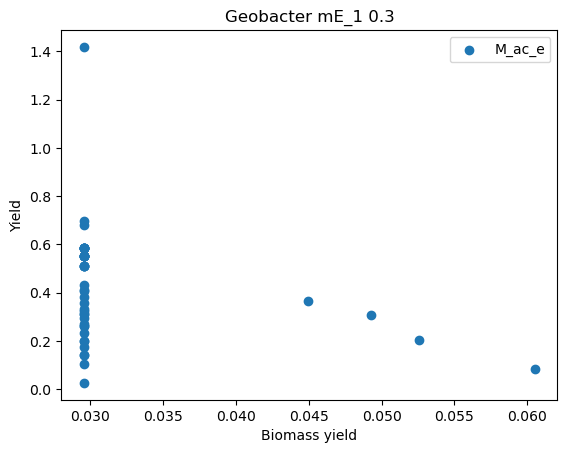

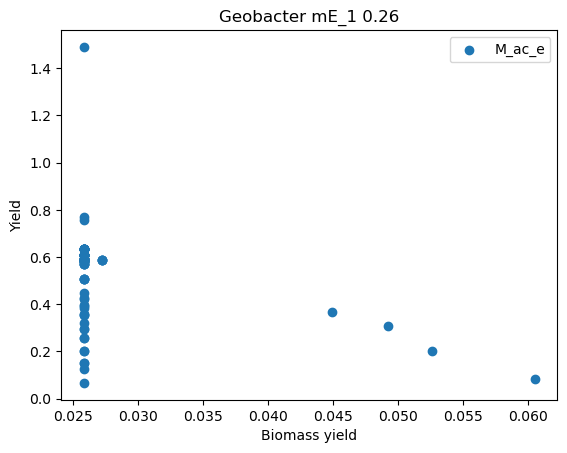

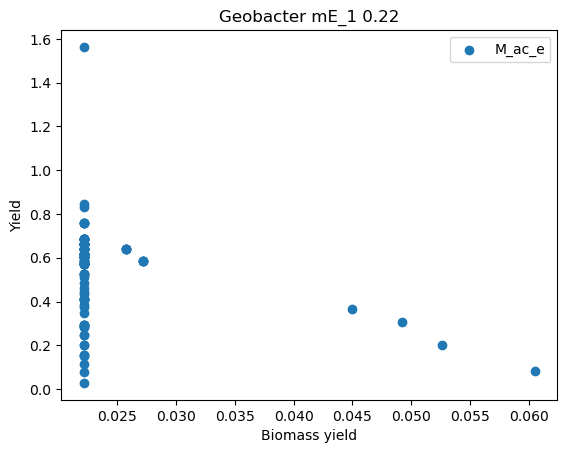

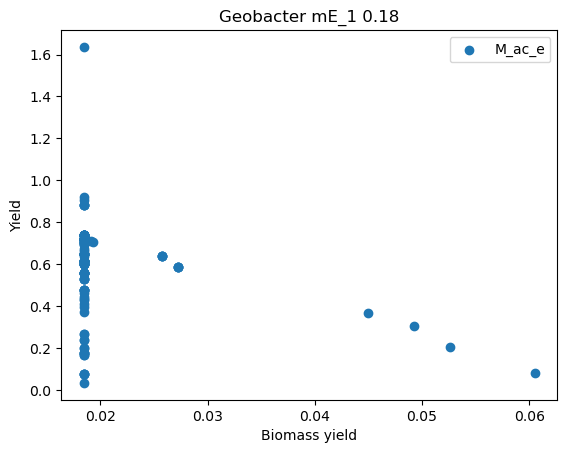

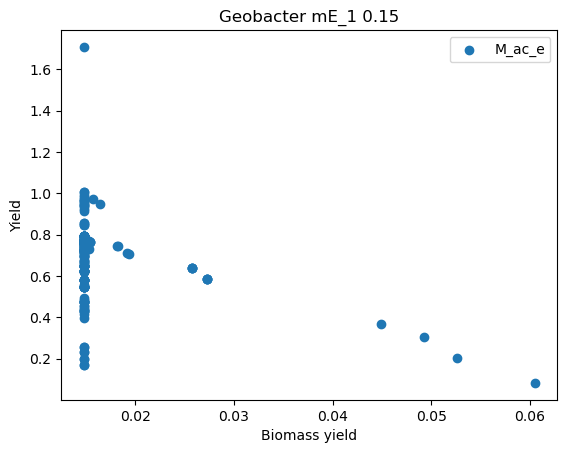

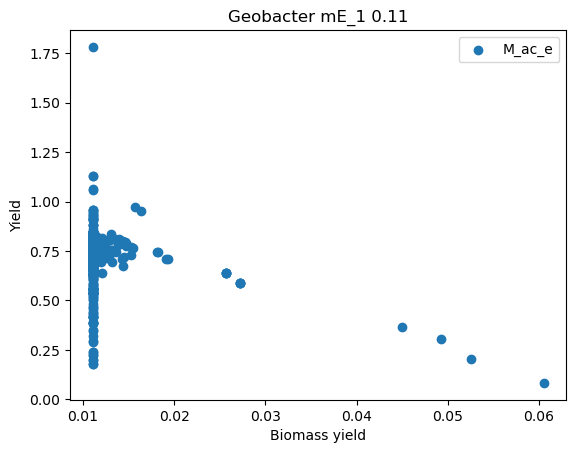

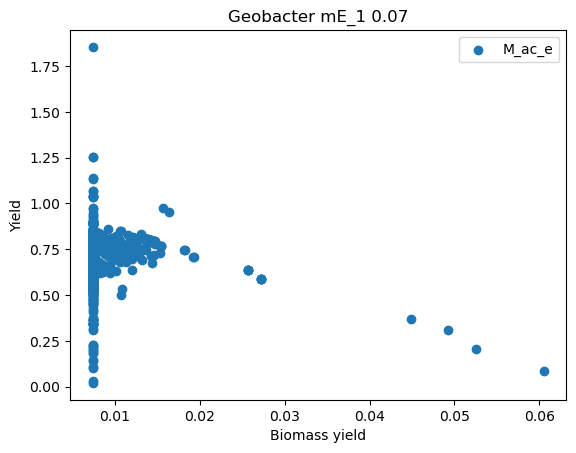

In [8]:
for model, dimes, in all_dimes.items():
    for dime_number, exchanges in dimes.items():
        c = c_sources[model][dime_number]
        sec = exchanges["secretion"]
        if not sec:
            continue
        for mu, ecms in filtered_ecms[model][dime_number].items():

            for met in sec:
                sec_yield = ecms[met]/ecms[c]
                bio_yield = ecms["objective"]/ecms[c]
                sec_name = re.sub(r"M_|__45__L|_e", "", met)

                plt.scatter(abs(bio_yield), abs(sec_yield), label=sec_name)
                plt.xlabel("Biomass yield")
                plt.ylabel("Yield")
                plt.title(f"{model} {dime_number} {mu}")
            plt.legend(sec)
            plt.show()


In [9]:
# for model, dime_ecms in filtered_ecms.items():
#     for dime, X in dime_ecms.items():

#         # 2. Standardize (important!)
#         X_scaled = StandardScaler().fit_transform(X)

#         # 3. Apply PCA
#         pca = PCA(n_components=2)
#         X_pca = pca.fit_transform(X_scaled)
#         var = pca.explained_variance_ratio_

#         plt.figure()
#         yields_dime = X["objective"]/X[c_sources[model][dime]]
#         sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=yields_dime)

#         plt.xlabel(f"PC1 ({var[0]*100:.1f}\\%)")
#         plt.ylabel(f"PC2 ({var[1]*100:.1f}\\%)")
#         plt.title(f"PCA {model} DiME {dime}")

#         met_name = re.sub(r"M_|__45__L|_e", "", c_sources[model][dime])
#         plt.colorbar(sc, label=f"Biomass yield on {met_name}")
#         plt.show()


In [10]:
def combine_ecms(ecms1, ecms2, allowed_uptakes):
    df1_t = ecms1.T
    df2_t = ecms2.T

    # 2. Get the union of all keys (rows) and fill missing with 0
    all_keys = df1_t.index.union(df2_t.index)
    df1_ext = df1_t.reindex(all_keys, fill_value=0)
    df2_ext = df2_t.reindex(all_keys, fill_value=0)

    # 3. Combine side‑by‑side (as columns)
    combined = pd.concat([df1_ext, df2_ext], axis=1, keys=["df1", "df2"])
    combined = combined[combined.index != "objective"]

    # Number all columns and split numbering by source
    n1 = df1_ext.shape[1]  # number of columns from df1
    n2 = df2_ext.shape[1]  # number of columns from df2

    new_cols = (
        [f"ECM1-{i+1}" for i in range(n1)] +
        [f"ECM2-{i+1}" for i in range(n2)]
    )
    combined.columns = new_cols

    # Create identity matrix as DataFrame
    identity = pd.DataFrame(
        -np.eye(len(combined)),           # n×n identity matrix
        index=combined.index, # same row index as combined
        columns=combined.index
    )
    # if the index is in allowed_uptakes, the entry in the matrix should be positive, otherwise negative
    mask = identity.index.isin(allowed_uptakes)
    # identity.loc[mask, mask] *= -1

    # rename columns
    I_cols = [f"S_{i.replace('M_', '')}" for i in combined.index]
    identity.columns = I_cols
    
    # Concatenate ECM columns and identity side‑by‑side
    combined_slack = pd.concat([combined, identity], axis=1)

    return combined, combined_slack

In [11]:
combos = {"mEmC_1": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_2": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_3": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_4": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_5": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_6": ["M_mal__45__L_e", "M_co2_e",  "M_fe2_e"],
          "mE_1": ["M_ac_e"]}
         

In [12]:
efmtool_inputs = {}

for dime_number, crossfed in combos.items():
    efmtool_inputs[dime_number] = {}

    for mu, ecms_geo in filtered_ecms["Geobacter"][dime_number].items():
        ecms_rho = filtered_ecms["Rhodoferax"][dime_number][mu]

        one_ecm = ecms_geo.iloc[0]
        medium_geobacter = list(one_ecm[one_ecm < 0].index)
        
        one_ecm = ecms_rho.iloc[0]
        medium_rhodoferax = list(one_ecm[one_ecm < 0].index)
    
        merged = medium_geobacter + medium_rhodoferax
        medium = [x for x in merged if x not in crossfed]
        allowed_uptakes = set(medium)
    
        combined, combined_slack = combine_ecms(ecms_geo, ecms_rho, allowed_uptakes)
    
        matrix = np.array(combined_slack)
        mets = list(combined.index)
        rxns = list(combined_slack.columns)
        revs = [0] * combined.shape[1]
        for met in combined_slack.index:
            if met in allowed_uptakes:
                revs.append(1)
            else:
                revs.append(0)

        efmtool_inputs[dime_number][mu] = (matrix, revs, rxns, mets)

In [ ]:
options = efmtool.get_default_options()
options['level'] = 'WARNING'

for dime_number, one_dime in efmtool_inputs.items():
    mus = sorted((float(k) for k in one_dime.keys()), reverse=True)
    for mu in mus:
        print(f"Running {dime_number} {mu}")

        try:
            _ = pd.read_csv(f"results/ecms2comp_{dime_number}_{mu}.csv")
            print(" * already done")
            continue
        except FileNotFoundError:
            pass

        matrix, revs, rxns, mets = one_dime[mu]
        efms_array = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
        
        print(f"{efms_array.shape[1]} EFMs")
        
        efms_nice = pd.DataFrame(efms_array, index=rxns)
        efms_nice = efms_nice.div(efms_nice.loc["S_virtual_tag_R_constraint_reaction"])
        #efms_nice.to_csv(f"results/ecms2exs_{dime_number}.csv")
        
        efms = efms_nice[efms_nice.index.str.startswith("ECM")]
        ecm1_frac = efms[efms.index.str.startswith("ECM1")].sum(axis=0)
        ecm2_frac = efms[efms.index.str.startswith("ECM2")].sum(axis=0)
        
        composition = pd.DataFrame({
            "Geobacter": ecm1_frac,
            "Rhodoferax": ecm2_frac
        })
        
        composition.to_csv(f"results/ecms2comp_{dime_number}_{mu}.csv")

Running mEmC_1 0.66
 * already done
Running mEmC_1 0.6
 * already done
Running mEmC_1 0.54
 * already done
Running mEmC_1 0.47
 * already done
Running mEmC_1 0.4
 * already done
Running mEmC_1 0.33
 * already done
Running mEmC_1 0.27
 * already done
Running mEmC_1 0.2


In [ ]:
composition

In [ ]:
matrix = np.array([[-1, 0, -1, 0, 0],
                   [1, -1, 0, -1, 0],
                   [0, 1, 0, 0, -1]])
revs = [0,0,1,0,0]
mets = ["A", "B", "C"]
rxns = ["ECM1", "ECM2", "SA", "SB", "SC"]

In [ ]:
efms = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
pd.DataFrame(efms, index = rxns)

In [ ]:
matrix = np.array([[-1, -1, 0, -1, 0, 0],
                   [1, 0.5, -1, 0, -1, 0],
                   [0, 0.5, 1, 0, 0, -1]])
revs = [0,0,0,1,0,0]
mets = ["A", "B", "C"]
rxns = ["ECM11", "ECM12", "ECM2", "SA", "SB", "SC"]

In [ ]:
efms = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
pd.DataFrame(efms, index = rxns)